# Deep Learning with TensorFlow and Keras: Incremental Capstone 10

## Problem Scenario
Advance deep learning and data engineering expertise through projects that apply neural networks and data processing techniques to real-world problems. This includes developing data aggregation and visualization modules for healthcare analytics, building predictive models for banking retention, applying computer vision for mask detection, leveraging hybrid models for sentiment analysis, and using autoencoders for medical image denoising. These projects emphasize model design, data handling, and evaluation to strengthen technical proficiency in supervised and unsupervised learning.

### Problem Objective
Develop CNN model across diverse domains through a hands-on project. 

Addresses distinct real-world challenges involving image data, emphasizing model design, data preprocessing, and performance evaluation. The projects promote practical understanding of CNNs through industry-relevant problem-solving using neural networks.

## Setup 

### Imports

In [47]:
# Standard library imports
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import json
import os 
import pprint

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset

from torchvision import datasets, transforms
import torchvision.transforms.v2 as v2
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

from sklearn.model_selection import train_test_split

torch.manual_seed(320)
np.random.seed(320)

print(torch.__version__)
print(torch.version.cuda)

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

2.10.0+cu126
12.6
Using device: cuda


### HyperParameters

In [2]:
batch_size = 64 #Training comes in around 5,000
initial_filters = 32 #Initial channel output 
n_conv_blocks = 3
learning_rate = 1e-4
epochs = 30     #Default to 10 for quick testing
dropout_rate = 0.25
print_every = 5 # Print training progress every n epochs
resize_ratio = 64 #Image resizing number
fc_units = [512, 256] #Fully Connected Unit values for Layer Classifier Block

# fc_unit_2 = 256

## 1. Load and Prepare Data

In [3]:
data_dir = Path('./data')
data_dir.mkdir(parents=True, exist_ok=True)

#Transform: convert to tensors and normalize RGB channels
# NOTE: Order matters, augmentations need to happen before ToTensor
train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),   #PIL is warning us there are transparency in these images, convert for CNN safety, they don't expect transparent pixels
    transforms.Resize((resize_ratio, resize_ratio)),  #Need same sized images 
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),(0.5,0.5,0.5)),
])

#Transform for validation and test but remove augmentations
val_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),   #PIL is warning us there are transparency in these images, convert for CNN safety, they don't expect transparent pixels
    transforms.Resize((resize_ratio, resize_ratio)),  #Need same sized images
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),(0.5,0.5,0.5)),
])

#ImageFolder is a class of torchvision.datasets so we can treat it as such
full_train_dataset = ImageFolder('./data', transform=train_transform)
full_val_dataset = ImageFolder('./data', transform=val_transform)

#Sanity Check
print(f'Classes: {full_train_dataset.classes}')
print(f'Class Indices: {full_train_dataset.class_to_idx}\n')

targets = np.array(full_train_dataset.targets)
indices = np.arange(len(full_train_dataset))

train_idx, temp_idx = train_test_split(
    indices,        #Split full dataset
    test_size=0.3,      #Use 30% of images for val and test
    stratify=targets,
    shuffle=True,
    random_state=320
)

val_idx, test_idx = train_test_split(
    temp_idx,       #Get indices of test from last train_test_split
    test_size=0.5,      #Split val and test equally
    stratify=targets[temp_idx],
    shuffle=True,
    random_state=320
)

#Create our variables for datasets later
train_dataset = Subset(full_train_dataset, train_idx)
val_dataset = Subset(full_val_dataset, val_idx)
test_dataset = Subset(full_val_dataset, test_idx)

print(f'Training Samples: {len(train_dataset)}')
print(f'Validation Samples: {len(val_dataset)}')
print(f'Test Samples: {len(test_dataset)}')
print(f'Image Shape: {train_dataset[0][0].shape}')


Classes: ['with_mask', 'without_mask']
Class Indices: {'with_mask': 0, 'without_mask': 1}

Training Samples: 5287
Validation Samples: 1133
Test Samples: 1133
Image Shape: torch.Size([3, 64, 64])


### 1.1 Create Dataloaders 

In [4]:
#Create our dataloaders from the train_test_split we made from the folders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f'Training Batches: {len(train_loader)}')

Training Batches: 83


### 1.2 CNN Architecture

In [5]:
#Create CNN def
def create_cnn(n_conv_blocks: int=2, dropout_rate: float=0.25, initial_filters: int=32):

    #Mask and No Mask
    num_classes = 2

    layers = []
    in_channels = 3     #RGB Input
    current_size = resize_ratio   #Image Input size

    for block_idx in range(n_conv_blocks):
        out_channels = initial_filters * (2 ** block_idx)

        # Conv -> BatchNorm -> ReLU -> Conv -> BatchNorm -> ReLU -> Pool -> Dropout
        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU())
        
        layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU())
        
        layers.append(nn.MaxPool2d(2, 2))
        layers.append(nn.Dropout(dropout_rate))
        
        in_channels = out_channels
        current_size //= 2

    # Calculate flattened size
    final_channels = initial_filters * (2 ** (n_conv_blocks - 1))
    # flattened_size = final_channels * current_size * current_size #We are going to look at this in 2D

    # Classifier (3 fully connected layers)
    layers.append(nn.AdaptiveAvgPool2d((1, 1)))
    layers.append(nn.Flatten())
    layers.append(nn.Linear(final_channels, fc_units[0]))
    layers.append(nn.ReLU())
    layers.append(nn.Dropout(dropout_rate))
    layers.append(nn.Linear(fc_units[0], fc_units[1]))
    layers.append(nn.ReLU())
    layers.append(nn.Dropout(dropout_rate))
    layers.append(nn.Linear(fc_units[1], num_classes))
    
    return nn.Sequential(*layers)

### 1.3 Train Model Def

In [6]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    checkpoint_path: str,
    epochs: int=10,
    print_every: int=1,
    device: torch.device = None,
):
    '''Training loop for PyTorch classification model.
    
    '''

    history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}

    for epoch in range(epochs):

        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            
            # Move batch to device if specified
            if device is not None:
                images, labels = images.to(device), labels.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Track metrics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Calculate training metrics
        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:
                
                # Move batch to device if specified
                if device is not None:
                    images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total

        # Record metrics
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_accuracy'].append(val_accuracy)

        # Print progress
        if (epoch + 1) % print_every == 0 or epoch == 0:

            print(
                f'Epoch {epoch+1}/{epochs} - ' +
                f'loss: {train_loss:.4f} - ' +
                f'accuracy: {train_accuracy:.2f}% - ' +
                f'val_loss: {val_loss:.4f} - ' +
                f'val_accuracy: {val_accuracy:.2f}%'
            )

        checkpoint = {
            "epoch": epochs,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }

        torch.save(checkpoint, checkpoint_path)

    print('\nTraining complete.')

    return history

### 1.4 Train Model Execution

In [7]:
# %%time

save_dir = Path('./artifacts')
save_dir.mkdir(exist_ok=True)

model = create_cnn(n_conv_blocks=n_conv_blocks, dropout_rate=dropout_rate, initial_filters=initial_filters).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
checkpoint_path = "artifacts/checkpoints.pth"

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    checkpoint_path=checkpoint_path,
    epochs=epochs,
    print_every=print_every,
    device=device,
)

c:\Users\gahhh\source\fullstack-projects\fullstack-projects\capstoneProject\.venv\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/30 - loss: 0.5396 - accuracy: 73.95% - val_loss: 0.4366 - val_accuracy: 81.99%
Epoch 5/30 - loss: 0.1796 - accuracy: 92.89% - val_loss: 0.1808 - val_accuracy: 92.67%
Epoch 10/30 - loss: 0.1363 - accuracy: 94.80% - val_loss: 0.1288 - val_accuracy: 94.97%
Epoch 15/30 - loss: 0.1002 - accuracy: 96.44% - val_loss: 0.1051 - val_accuracy: 95.94%
Epoch 20/30 - loss: 0.0819 - accuracy: 97.13% - val_loss: 0.1475 - val_accuracy: 94.44%
Epoch 25/30 - loss: 0.0660 - accuracy: 97.60% - val_loss: 0.1003 - val_accuracy: 96.20%
Epoch 30/30 - loss: 0.0623 - accuracy: 97.92% - val_loss: 0.0927 - val_accuracy: 96.65%

Training complete.


### 1.5 Evaluate and Visualize Results

In [8]:
def evaluate_model(
    model: nn.Module,
    test_loader: DataLoader,
    device: torch.device = None
) -> tuple[float, np.ndarray, np.ndarray]:
    '''Evaluate model on test set.

    '''

    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:
            
            # Move batch to device if specified
            if device is not None:
                images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    return accuracy, np.array(all_predictions), np.array(all_labels)

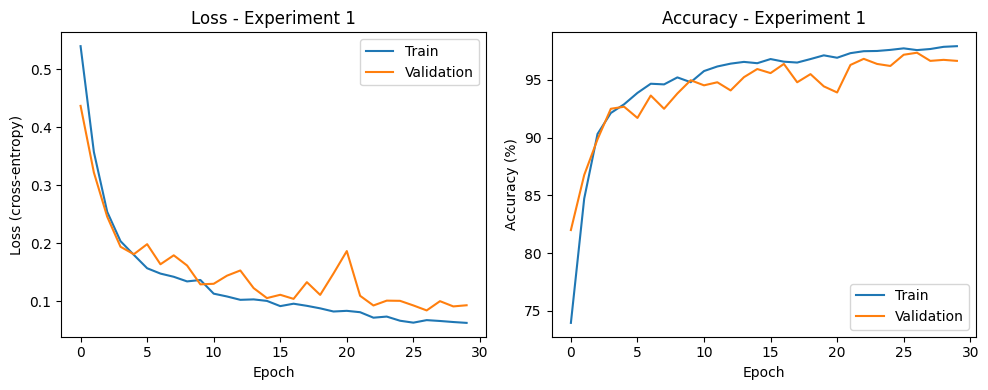


Test Accuracy: 97.18%


In [9]:
# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Loss - Experiment 1')
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (cross-entropy)')
axes[0].legend(loc='best')

axes[1].set_title('Accuracy - Experiment 1')
axes[1].plot(history['train_accuracy'], label='Train')
axes[1].plot(history['val_accuracy'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

# Test accuracy
test_accuracy, predictions, true_labels = evaluate_model(model, test_loader, device)
print(f'\nTest Accuracy: {test_accuracy:.2f}%')

### 1.6 Save Model and Metadata

In [10]:
model_path = f'{save_dir}/mask_cnn.pth'

torch.save(
    model.state_dict(),
    model_path
)


df = pd.DataFrame(history)
df.to_csv(f'{save_dir}/training_history.csv', index=False)

now = datetime.now(ZoneInfo('America/New_York')).isoformat()
metadata_path = f'{save_dir}/metadata.json'
metadata_entry = {
    "model": "GentralsCNN",
    "test_accuracy": test_accuracy,
    "num_classes": 2,
    "image_size": (resize_ratio, resize_ratio),
    "fc_units": fc_units,
    "optimizer": "Adam",
    "learning_rate": learning_rate,
    "epochs": epochs,
    "n_conv_blocks": n_conv_blocks,
    "initial_filters": initial_filters,
    "batch_size": train_loader.batch_size,
    "dropout_rate": dropout_rate,
    "transforms": str(train_transform.transforms),
    "device": str(device),
    "date": now
}

#Load file or create file for metadata
if os.path.exists(metadata_path):
    with open(metadata_path, "r") as file:
        try:
            metadata = json.load(file)
        except json.JSONDecodeError:
            metadata = {}
else:
    metadata = {}

# Append new entry
metadata[now] = metadata_entry

#Write back to file
with open(metadata_path, "w") as file:
    json.dump(metadata, file, indent=4)


### 1.7 Obervations



Going through the hyperparameters I learned a lot about model's and noisy data that doesn't help as well as the necessity of needing well documented results. Understanding when a model is too big and too complicated for a dataset is a learning lesson I would need to learn through trial and error. I need a better understanding of conceptualizing the size model's deal with vs the size of data it is going through. Such as, if the data is 64K features should the model be creating a million parameters to process? Should it be similar in size? maybe 2 times the size? These are all questions I've been asking myself instead of blindly plugging in hyperparameters. I've documented the results of each of my trainings (with some missing from initial testing) in the metadata JSON file showing as much of the model and changes as I could, sorted by date time of execution. Overall I understand Epochs are very important BUT i think the most important hyper parameters to watch are batch_sizes and fc_units are the most important parameters to think about. How much does the model need to see? smaller CAN be better if the data size is relatively small or the image is relatively simple. Or does it need more data sent to each channel for detailed info such as the face in this case? There are many other things to think about and getting there will take much more practice. 

- Reshaping to a 32 x 32 image resize was **TOO SMALL** the model couldn't figure out the details of the picture being so compressed.
- Reshaping to a 128 x 128 image resize was **TOO BIG** for sending to my GPU device of 12GB, reducing to 64 x 64  was just under max memory
- Having 64 x 64 is good enough for our purpose with training with and without **augmentation** from our transform. (Put this in the metadata for tracking changes)
- Training Models requires a good well detailed file results management file for tracking changes and best results
- Increasing fc_units does not guarantee an increased accuracy, using a too big classification block could cause issues with figuring out how to train.
- Increasing the starting fc_unit increased our accuracy slightly, I assume this is due to the model being able to evaluate on a bigger neuron scale before reducing size to classify an image.
- Adding another Layer to the layer block didn't increase the accuracy much from our 3 layer connection
- Removing the layer, increasing conv_blocks and changing the inital_filters channels ruined our accuracy, but this could be due to lower epochs, training speed also significantly increased by 10.333 times faster.
- Decreasing batch_size was the **GREATEST** increase in accuracy for our model. 64 was a jump of 5%.
- Final run was increasing epochs for more training, and we got another expected jump of 2.5%!

### Find best final accuracy

In [51]:
#Get best accuracy
if os.path.exists(metadata_path):
    with open(metadata_path, "r") as file:
        try:
            metadata = json.load(file)
            accuracy_results = []

            for key, data in metadata.items():
                if 'test_accuracy' in  data:
                    accuracy_results.append(data)
            
            sorted_list = sorted(accuracy_results, key=lambda x: x['test_accuracy'], reverse=True)
            print(f'Best Accuracy: {sorted_list[0]['test_accuracy']}\n')
            pprint.pprint(sorted_list[0], indent=4)
        except json.JSONDecodeError:
            metadata = {}
else:
    metadata = {}



Best Accuracy: 97.1756398940865

{   'batch_size': 64,
    'date': '2026-02-09T19:47:12.306213-05:00',
    'device': 'cuda',
    'dropout_rate': 0.25,
    'epochs': 30,
    'fc_units': [512, 256],
    'image_size': [64, 64],
    'initial_filters': 32,
    'learning_rate': 0.0001,
    'model': 'GentralsCNN',
    'n_conv_blocks': 3,
    'num_classes': 2,
    'optimizer': 'Adam',
    'test_accuracy': 97.1756398940865,
    'transforms': '[Lambda(), Resize(size=(64, 64), interpolation=bilinear, '
                  'max_size=None, antialias=True), '
                  'RandomHorizontalFlip(p=0.5), RandomRotation(degrees=[-10.0, '
                  '10.0], interpolation=nearest, expand=False, fill=0), '
                  'ToTensor(), Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, '
                  '0.5))]'}
